# Project: Credit Risk Analysis & Loan Default Prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns 

## Read DataSet

In [2]:
df = pd.read_csv("credit_risk_dataset.csv") 
df 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


## Dataset information

In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


## Find Null Values

In [4]:
df.isnull().sum() 

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [5]:
df.shape 

(32581, 12)

## Filled Null Values in person_emp_length 

In [6]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].mean())

## Filled Null values in interest rate

In [7]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mean())

## Find outlier in Person Age

In [8]:
df[df['person_age']>100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.570000,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.860000,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.250000,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,11.011695,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.730000,0,0.00,N,25


## Remove Outliers in Person Age
### Ages greater than 100 are considered unrealistic for this dataset and are treated as outliers.
### These records are removed to improve data quality and analysis accuracy.

In [9]:
df = df.drop(df[df['person_age']>100].index) 

In [10]:
df[df['person_age']>100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


## Find out Outlier in Person Employeement Length (> 80)

In [11]:
df[df["person_emp_length"]>80]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


## Drop records with employment length > 80
### Employment lengths above 80 years are unrealistic and are treated as outliers.

In [12]:
df = df.drop(df[df["person_emp_length"]>80].index)

In [13]:
df[df["person_emp_length"]>80]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


# Customer Demographics

## 1. What is the age distribution of customers?

In [ ]:
df['Age_Group'] = pd.cut(
    df["person_age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

df['Age_Group'].value_counts().sort_index() 

Age_Group
18-25    15350
26-35    13763
36-45     2814
46-55      513
56-65      104
65+         30
Name: count, dtype: int64

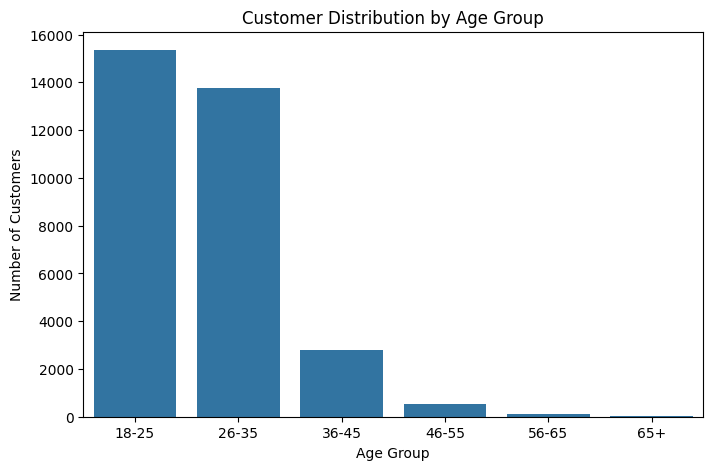

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Age_Group',data= df )

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

## 2. Which age group has the highest default rate?

  ###  Loan status (0 is non default 1 is default)

In [16]:
pd.crosstab(
    df['Age_Group'],
    df['loan_status'],
    normalize='index'
) * 100

loan_status,0,1
Age_Group,,
18-25,76.977199,23.022801
26-35,79.321369,20.678631
36-45,79.282161,20.717839
46-55,78.167641,21.832359
56-65,74.038462,25.961538
65+,83.333333,16.666667


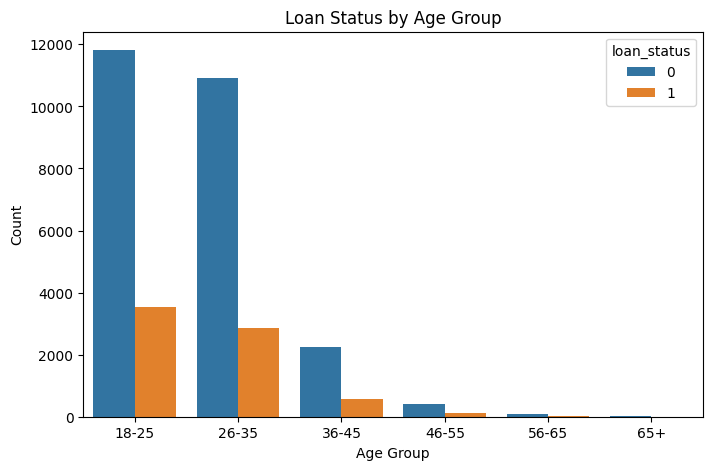

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age_Group', hue='loan_status')

plt.title('Loan Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

## 3. NoN default VS Default Count

In [18]:
df['loan_status'].value_counts()

loan_status
0    25467
1     7107
Name: count, dtype: int64

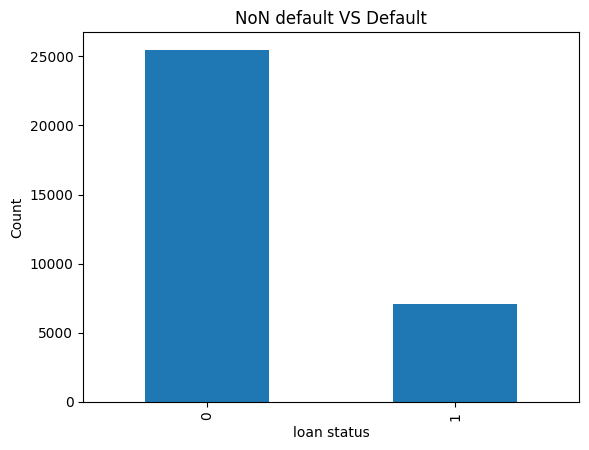

In [19]:
df['loan_status'].value_counts().plot(kind='bar')

plt.title('NoN default VS Default')
plt.xlabel('loan status')
plt.ylabel('Count')
plt.show()

## 4. income vs loan status

In [20]:
df.groupby('loan_status')['person_income'].mean()


loan_status
0    70554.030628
1    49124.262839
Name: person_income, dtype: float64

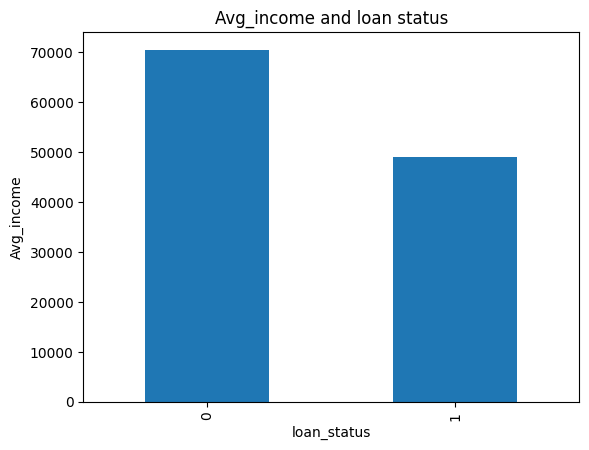

In [21]:
df.groupby('loan_status')['person_income'].mean().plot(kind='bar')

plt.title('Avg_income and loan status')
plt.ylabel('Avg_income')
plt.show()

# 5. What is the income distribution of customers?

In [22]:
df['person_income'].describe()

count    3.257400e+04
mean     6.587848e+04
std      5.253194e+04
min      4.000000e+03
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
max      2.039784e+06
Name: person_income, dtype: float64

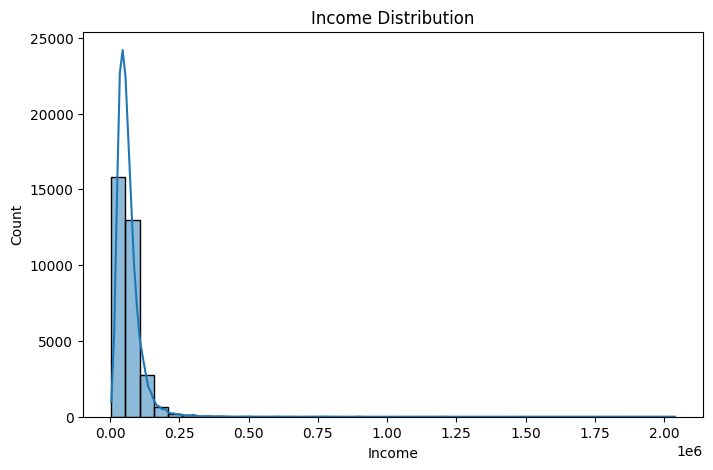

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['person_income'], bins=40, kde=True)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show() 

## 6. Which home ownership type has the highest loan default rate?

In [24]:
home_default = df.groupby('person_home_ownership')['loan_status'].mean()*100

home_default.sort_values(ascending=False)

person_home_ownership
RENT        31.571585
OTHER       30.841121
MORTGAGE    12.573469
OWN          7.469040
Name: loan_status, dtype: float64

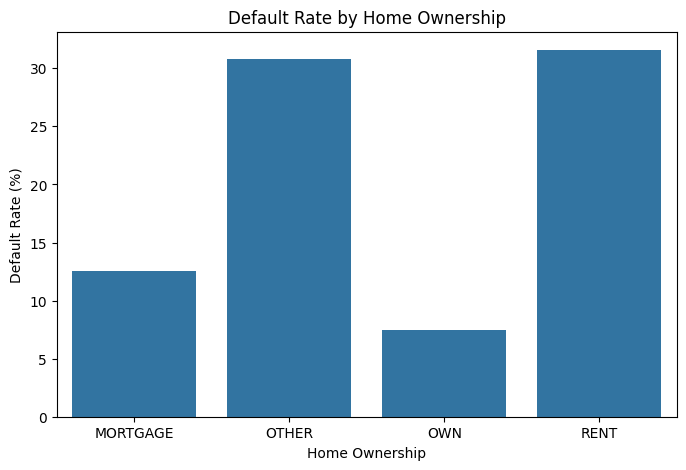

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=home_default.index,
    y=home_default.values
)

plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
plt.show()

## 7. Which loan intent/purpose has the highest default rate?

In [26]:
loan_intent_default = (
    df.groupby('loan_intent')['loan_status']
      .mean()*100
)

loan_intent_default.sort_values(ascending=False)

loan_intent
DEBTCONSOLIDATION    28.587874
MEDICAL              26.700708
HOMEIMPROVEMENT      26.102635
PERSONAL             19.876789
EDUCATION            17.222136
VENTURE              14.818055
Name: loan_status, dtype: float64

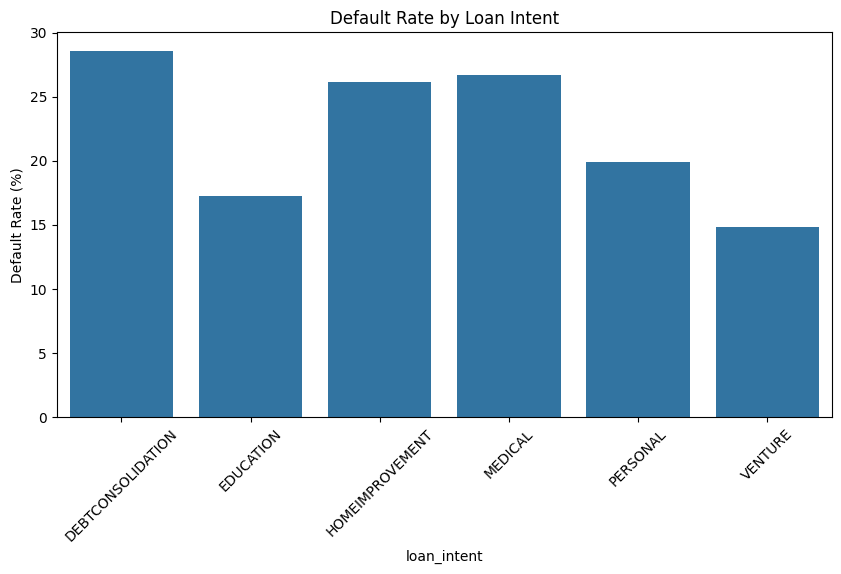

In [27]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=loan_intent_default.index,
    y=loan_intent_default.values
)

plt.xticks(rotation=45)
plt.title('Default Rate by Loan Intent')
plt.ylabel('Default Rate (%)')
plt.show()

## 8. Which loan grade is most risky?

In [28]:
grade_default = (
    df.groupby('loan_grade')['loan_status']
      .mean()*100
)

grade_default.sort_values(ascending=False)

loan_grade
G    98.437500
F    70.539419
E    64.419087
D    59.034483
C    20.740397
B    16.280628
A     9.957313
Name: loan_status, dtype: float64

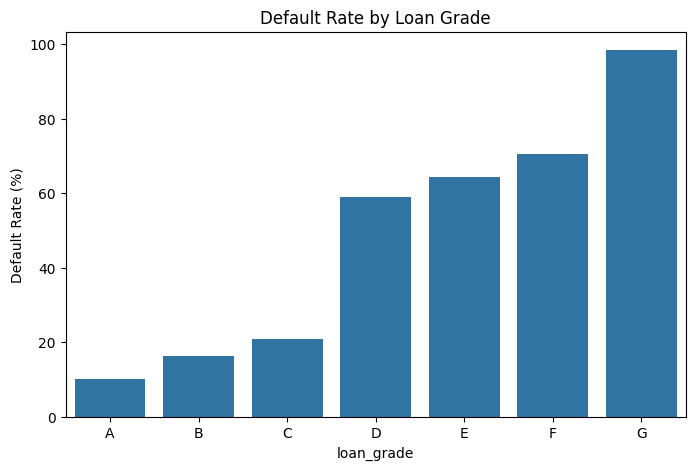

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=grade_default.index,
    y=grade_default.values
)

plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Rate (%)')
plt.show()

## 6. What is the overall default rate?

In [30]:
default_rate = df['loan_status'].mean()*100

print(f"Overall Default Rate: {default_rate:.2f}%")

Overall Default Rate: 21.82%


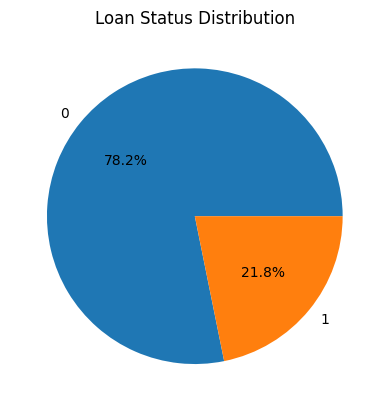

In [ ]:
df['loan_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Loan Status Distribution')
plt.ylabel('')
plt.show() 

## 7. How does loan amount affect default?

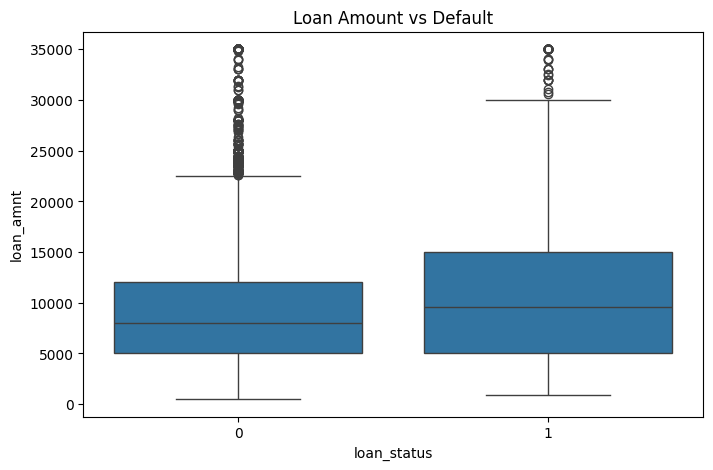

In [32]:
df.groupby('loan_status')['loan_amnt'].mean()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='loan_status',
    y='loan_amnt',
    data=df
)

plt.title('Loan Amount vs Default')
plt.show() 

## 8. Do customers with higher interest rates default more?

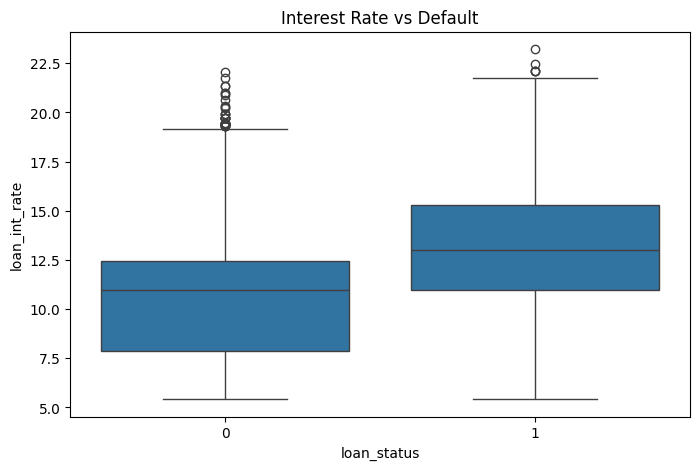

In [33]:
df.groupby('loan_status')['loan_int_rate'].mean()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='loan_status',
    y='loan_int_rate',
    data=df
)

plt.title('Interest Rate vs Default')
plt.show() 

## 9. Do customers with higher loan_percent_income default more often?

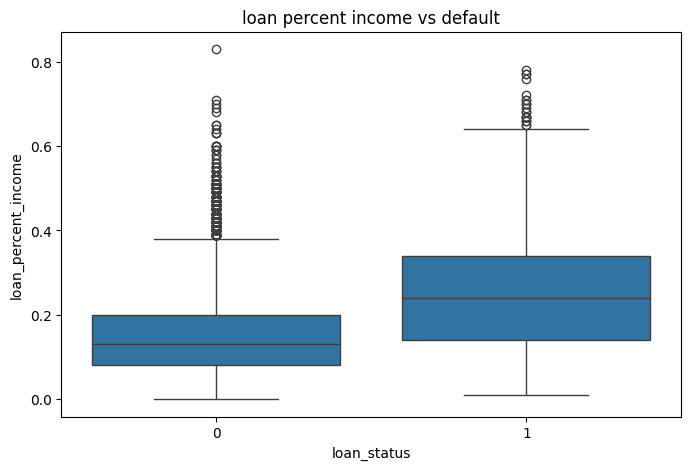

In [34]:
df.groupby('loan_status')['loan_percent_income'].mean()

plt.figure(figsize= (8,5))
sns.boxplot(
    x= 'loan_status',
    y= 'loan_percent_income',
    data=df
)

plt.title('loan percent income vs default')
plt.show()

## 10. What is the relationship between income and loan amount?

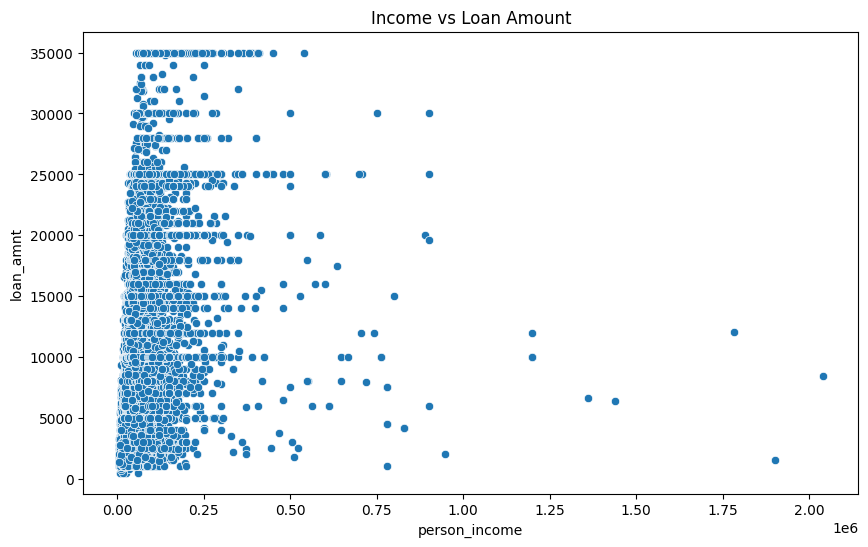

In [35]:
df[['person_income','loan_amnt']].corr()

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='person_income',
    y='loan_amnt',
    data=df
)

plt.title('Income vs Loan Amount')
plt.show() 

## 11. Does employment length affect loan default?

In [36]:
emp_default = (
    df.groupby('person_emp_length')['loan_status']
      .mean()*100
) 

emp_default 

person_emp_length
0.000000      27.941535
1.000000      27.650086
2.000000      25.649688
3.000000      20.138889
4.000000      21.239554
4.789686      31.508380
5.000000      18.601494
6.000000      18.754689
7.000000      18.769932
8.000000      16.656787
9.000000      17.849305
10.000000     17.097701
11.000000     18.378378
12.000000     15.679443
13.000000     11.971831
14.000000     16.716418
15.000000     18.067227
16.000000     12.121212
17.000000     17.054264
18.000000     10.576923
19.000000     14.062500
20.000000     30.952381
21.000000     26.315789
22.000000     15.789474
23.000000     30.000000
24.000000     30.000000
25.000000      0.000000
26.000000     16.666667
27.000000     20.000000
28.000000      0.000000
29.000000    100.000000
30.000000     50.000000
31.000000      0.000000
34.000000    100.000000
38.000000      0.000000
41.000000      0.000000
Name: loan_status, dtype: float64

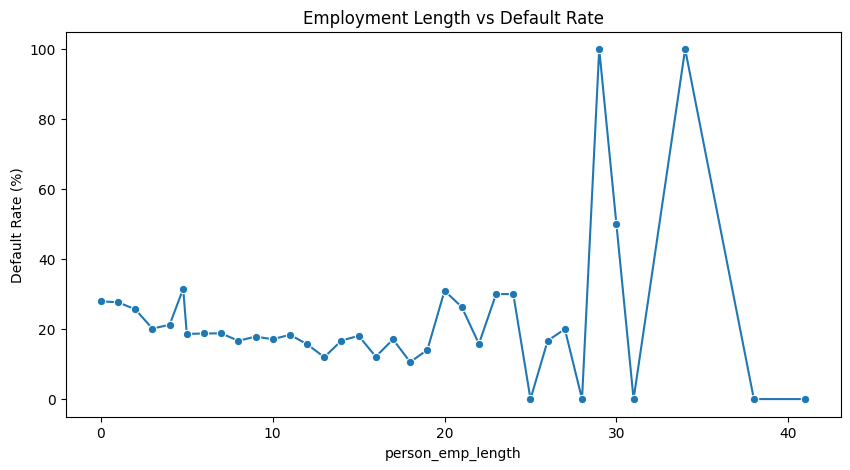

In [37]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x=emp_default.index,
    y=emp_default.values,
    marker='o'
)

plt.title('Employment Length vs Default Rate')
plt.ylabel('Default Rate (%)')
plt.show()

## 12. Do customers with previous default history default more?

In [38]:
default_history = (
    df.groupby('cb_person_default_on_file')['loan_status']
      .mean()*100
) 

default_history

cb_person_default_on_file
N    18.397316
Y    37.795961
Name: loan_status, dtype: float64

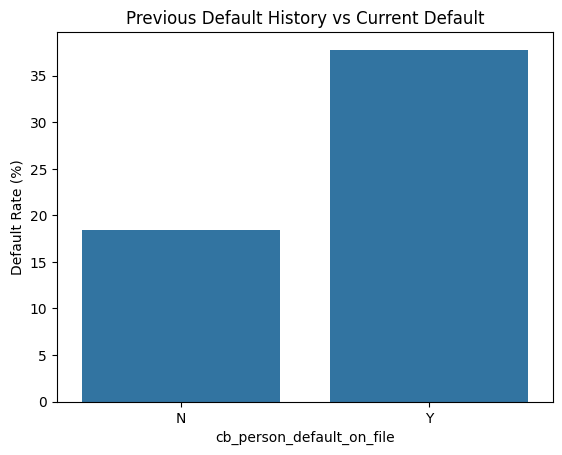

In [39]:
sns.barplot(
    x=default_history.index,
    y=default_history.values
)

plt.title('Previous Default History vs Current Default')
plt.ylabel('Default Rate (%)')
plt.show() 

## 13. What is the default rate by credit history length?

In [40]:
credit_history = (
    df.groupby('cb_person_cred_hist_length')['loan_status']
      .mean()*100
)

credit_history.head()

cb_person_cred_hist_length
2    23.574782
3    22.272727
4    22.319770
5    20.627326
6    20.786214
Name: loan_status, dtype: float64

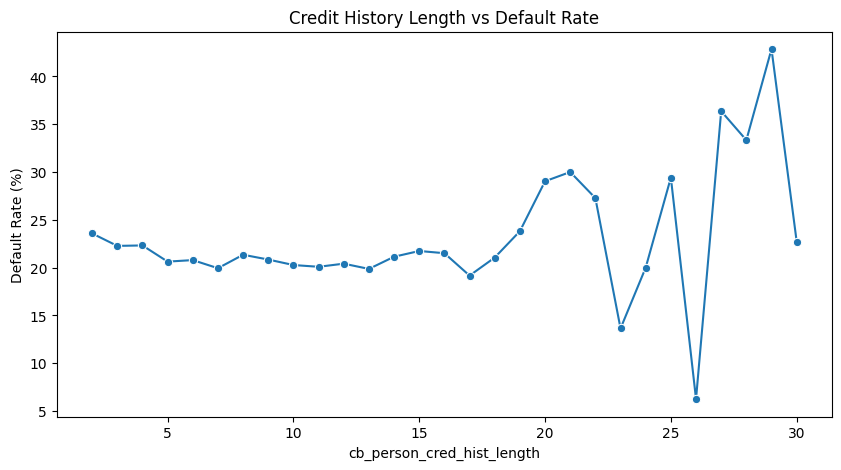

In [41]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x=credit_history.index,
    y=credit_history.values,
    marker='o'
)

plt.title('Credit History Length vs Default Rate')
plt.ylabel('Default Rate (%)')
plt.show()

## 14. Which loan intent has the highest average loan amount?

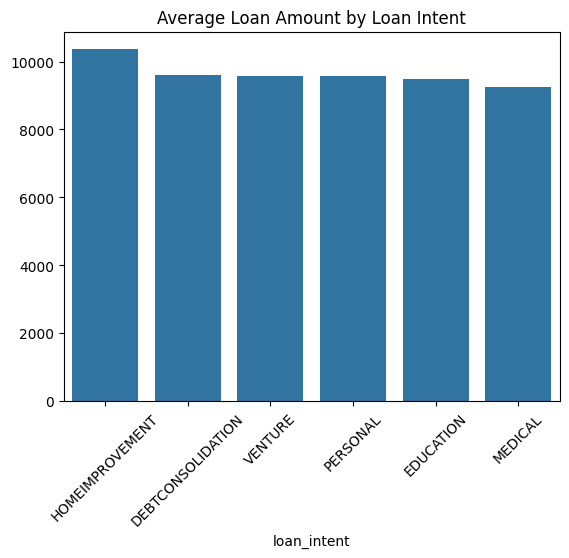

In [42]:
df.groupby('loan_intent')['loan_amnt']\
  .mean()\
  .sort_values(ascending=False)
  
avg_loan = (
    df.groupby('loan_intent')['loan_amnt']
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=avg_loan.index,
    y=avg_loan.values
)

plt.xticks(rotation=45)
plt.title('Average Loan Amount by Loan Intent')
plt.show()

## 15. Which loan grade has the highest interest rate?

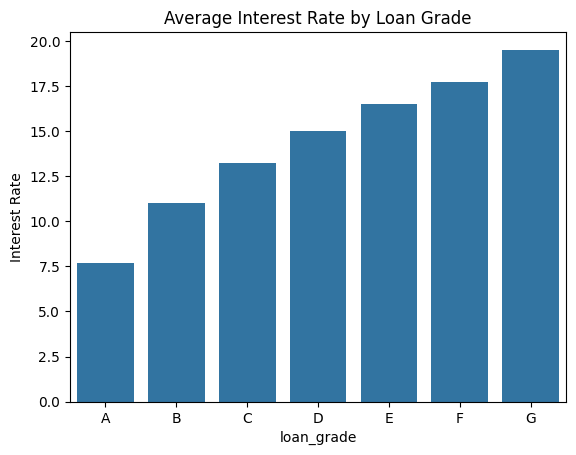

In [43]:
df.groupby('loan_grade')['loan_int_rate']\
  .mean()\
  .sort_values(ascending=False)
  
avg_interest = (
    df.groupby('loan_grade')['loan_int_rate']
      .mean()
)

sns.barplot(
    x=avg_interest.index,
    y=avg_interest.values
)

plt.title('Average Interest Rate by Loan Grade')
plt.ylabel('Interest Rate')
plt.show()

## 16. What customer profile is high risk?

In [44]:
risk_profile = df.groupby(
    [
        'person_home_ownership',
        'loan_grade',
        'cb_person_default_on_file'
    ]
)['loan_status'].mean()*100

risk_profile.sort_values(ascending=False).head(20)

person_home_ownership  loan_grade  cb_person_default_on_file
MORTGAGE               G           N                            100.000000
                                   Y                            100.000000
OWN                    G           Y                            100.000000
OTHER                  E           N                            100.000000
                       F           Y                            100.000000
                                   N                            100.000000
RENT                   G           N                            100.000000
OWN                    G           N                            100.000000
RENT                   G           Y                             94.117647
OWN                    F           N                             80.000000
RENT                   E           N                             78.424658
                       F           N                             78.260870
                                   Y   

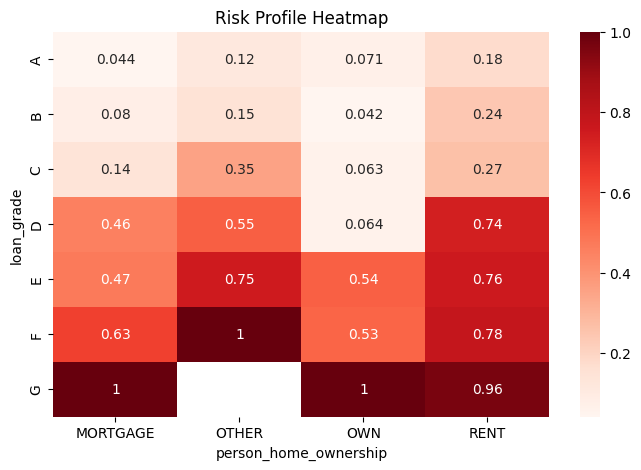

In [45]:
risk_heatmap = pd.pivot_table(
    df,
    values='loan_status',
    index='loan_grade',
    columns='person_home_ownership',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(
    risk_heatmap,
    annot=True,
    cmap='Reds'
)

plt.title('Risk Profile Heatmap')
plt.show()

97538532